# Fitting photometry: more parameters, and how to trust the fit

[`00_quickstart`](00_quickstart.py) ran a fit and showed the posterior SED,
SFH, and corner. This notebook keeps that exact machinery — `SEDModel.build`
with the `WavePrecomp` lookup table, a prewarmed two-chain NUTS run — and
extends it in the two ways that matter for real work:

1. **More free parameters.** On top of the quickstart's SFH + birth-cloud
   dust, we free the stellar **metallicity** and the **diffuse** dust optical
   depth. That opens the classic age–metallicity–dust degeneracy, which is
   the thing broadband photometry struggles with.
2. **Verifying the posterior.** The second half is the part the quickstart
   skips: per-parameter split-R̂ and effective sample size, divergence count,
   chain traces, and a posterior-predictive χ². These are what let you say a
   credible interval means something.

In [1]:
from _setup import effective_wavelengths_um, quiet

quiet()

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    builders,
    cosmology,
    generate_mock,
    load_ssp_data,
    plot,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

## Stellar library and observation

The same UV–MIR bandset as the quickstart (GALEX → WISE), bare-stellar SSP.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"
ssp_path = Path("../data") / f"{SSP_NAME}.h5"
if not ssp_path.exists():
    # Public API: fetches the grid on first use and caches it under data/.
    ssp_path = Path(tengri.download_ssp(SSP_NAME))
ssp = load_ssp_data(str(ssp_path))

FILTERS = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "2mass_j",
    "2mass_h",
    "2mass_ks",
    "wise_w1",
    "wise_w2",
    "wise_w3",
    "wise_w4",
]
obs = Observation(photometry=Photometry.from_names(FILTERS))

## Build the model

The quickstart's model, plus two extra free parameters: stellar metallicity
(`stellar={"met_logzsol": ...}`) and the diffuse dust optical depth. Eight
free parameters in all. `approx=WavePrecomp()` precomputes the SSP × filter
integrals so the warm forward pass stays in the millisecond range — what
makes a prewarmed two-chain NUTS run finish in seconds.

In [3]:
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=WavePrecomp(),
    sfh=builders.sfh.tsnorm(defaults=FREE),
    dust=builders.dust.two_component(
        defaults=FIXED,
        law_bc="calzetti",
        tau_bc=Uniform(0.0, 1.0),
        tau_diff=Uniform(0.0, 1.0),
        emission=builders.dust.emission.modified_blackbody(defaults=FIXED),
    ),
    neb=builders.neb.none(),
    stellar={"met_logzsol": Uniform(-1.5, 0.3)},
    redshift=Fixed(0.05),
)
forward = ForwardModel.build(sed=sed_model)
print(sed_model.summary())
print(f"\nFree parameters ({sed_model.spec.n_free}): {', '.join(sed_model.spec.free_params)}")

Model  SFH: tsnorm
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     14 bands
  Redshift:    0.0500 (fixed)
  Dtype:       float64
  Fast path:   photometry LUT
  Components:  dust_emission=modified_blackbody, igm

  Pipeline (5 components):
    1. stellar        [sfh_model=tsnorm, metallicity_model=delta, n_grid=256]
    2. nebular        [backend=baked_in]
    3. dust           [law_bc=calzetti, law_diff=calzetti]
    4. dust_emission
    5. igm

  Parameters:  8 free
──────────────────────────────────────────────────────────────────

Free parameters (8): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_tsnorm_log_total_mass, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_skew, sfh_tsnorm_trunc, sfh_tsnorm_width_gyr


## Mock observation

One draw from the prior is the truth (so the truth is always inside the
prior — no chance of the broken "truth outside the prior" setup). SNR = 20 is
realistic for a survey source.

In [4]:
key = jax.random.PRNGKey(7)
key_truth, key_mock, key_fit = jax.random.split(key, 3)

truth = sed_model.spec.sample(key_truth)
mock = generate_mock(sed_model, truth, key=key_mock, snr=20.0)
flux_obs = np.asarray(mock["flux_obs"])
noise = np.asarray(mock["noise"])

phot = obs.photometry
wave_eff_um = effective_wavelengths_um(phot)
print(f"Mock: {len(flux_obs)} bands, SNR = 20")

Mock: 14 bands, SNR = 20


## Fit

`forward.prewarm` compiles the sampler stack and runs NUTS window adaptation
once; the subsequent `forward.fit` reuses that compile cache. We use two
parallel chains (via `jax.vmap`) — enough for a genuine cross-chain split-R̂,
and the `vmap` memory scales with the chain count, so two keeps the peak well
clear of the jetsam threshold on a laptop (see docs/dev/notebook_orchestration_oom.md).

In [5]:
t = time.perf_counter()
forward.prewarm(method="mcmc_nuts", n_chains=2)
print(f"  prewarm wall: {time.perf_counter() - t:6.2f} s")

map_result = forward.fit(flux_obs, noise, method="map", key=key_fit, n_steps=200)

t = time.perf_counter()
posterior = forward.fit(
    flux_obs,
    noise,
    method="mcmc_nuts",
    key=key_fit,
    n_warmup=600,
    n_samples=600,
    n_chains=2,
    n_burnin=0,
)
print(f"  NUTS wall (2 chains × 600 = 1200 samples): {time.perf_counter() - t:6.2f} s")
posterior.summary()

  prewarm wall:  36.01 s


    step 200: loss=3211.8025
  MAP (ADAM) complete in 0.9s, 200 steps, loss=3211.8025


  MAP initialization: reusing cached MAP point


  NUTS wall (2 chains × 600 = 1200 samples):  89.30 s
Posterior  method: NUTS (BlackJAX)  samples: 600  wall_time: 88.3s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_L_agn_ir                   0.0000    0.0000    0.0000       —
  dust_Rv                         3.1000    3.1000    3.1000       —
  dust_T                         35.0000   35.0000   35.0000       —
  dust_T_cold                    20.0000   20.0000   20.0000       —
  dust_T_warm                    45.0000   45.0000   45.0000       —
  dust_alpha                      2.0000    2.0000    2.0000       —
  dust_alpha_dale                 2.0000    2.0000    2.0000       —
  dust_alpha_dl14                 2.0000    2.0000    2.0000       —
  dust_alpha_mir                  2.0000    2.0000    2.0000       —
  dust_beta_cold                  2.0000    2.0000    2

## Convergence

Before any science: did the chains converge? Split-R̂ should be < 1.01,
effective sample size (ESS) a healthy fraction of the 1200 draws, and
divergences few. Anything failing here means the credible intervals are not
trustworthy.

In [6]:
rhat = posterior.rhat()
ess = posterior.ess() if hasattr(posterior, "ess") else {}
n_div = posterior.diagnostics.get("n_divergent", "n/a")

print(f"{'parameter':<28}{'R̂':>8}{'ESS':>9}")
print("-" * 45)
for p in rhat:
    e = ess.get(p)
    estr = "—" if e is None else f"{float(e):.0f}"
    print(f"{p:<28}{float(rhat[p]):>8.4f}{estr:>9}")
rhat_max = max(float(v) for v in rhat.values())
print(f"\nmax R̂ = {rhat_max:.4f}   divergences = {n_div}   (2 chains × 600 draws)")

parameter                         R̂      ESS
---------------------------------------------
dust_tau_bc                   0.9984        —
dust_tau_diff                 0.9984        —
met_logzsol                   0.9983        —
sfh_tsnorm_log_total_mass     0.9984        —
sfh_tsnorm_peak_lbt_gyr       1.0030        —
sfh_tsnorm_skew               0.9997        —
sfh_tsnorm_trunc              1.0162        —
sfh_tsnorm_width_gyr          1.0333        —

max R̂ = 1.0333   divergences = 36   (2 chains × 600 draws)


Chain traces for the three parameters that drive the degeneracy — stellar
mass, metallicity, diffuse dust. Well-mixed chains overlap and look like
white noise; a trapped chain wanders or separates.

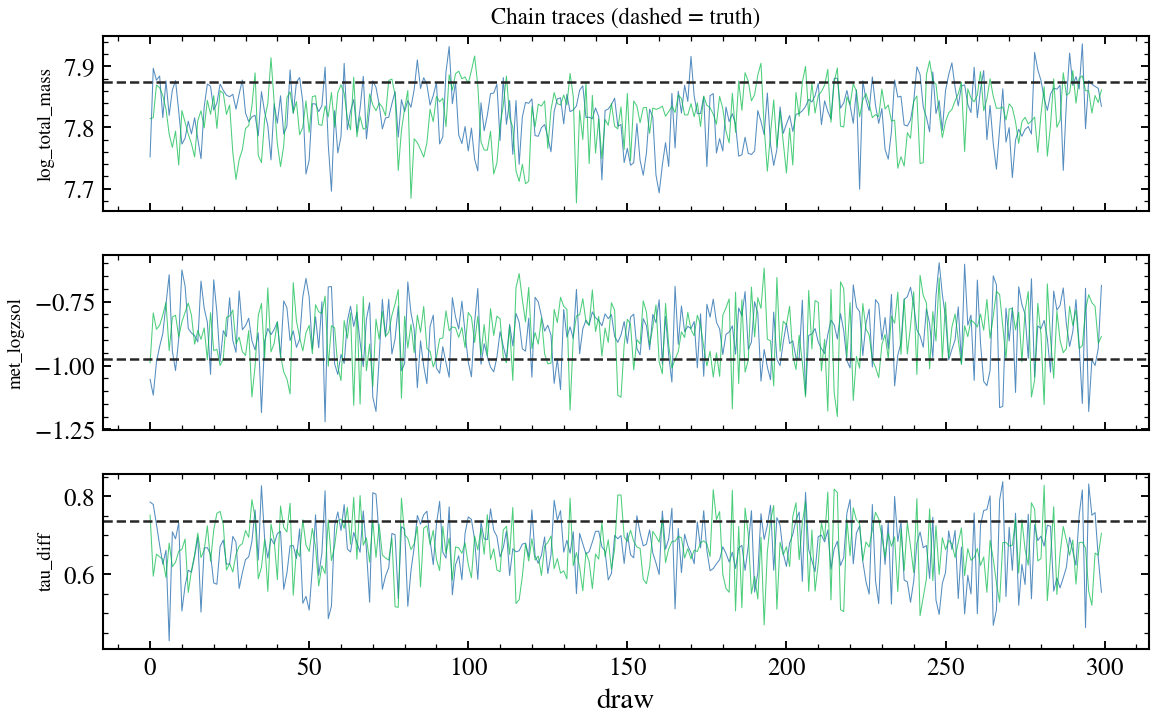

In [7]:
trace_params = [
    p
    for p in ("sfh_tsnorm_log_total_mass", "met_logzsol", "dust_tau_diff")
    if p in posterior.samples
]
fig_tr, axes_tr = plt.subplots(
    len(trace_params), 1, figsize=(8.0, 1.7 * len(trace_params)), sharex=True
)
if len(trace_params) == 1:
    axes_tr = [axes_tr]
for ax_t, p in zip(axes_tr, trace_params):
    chains = np.asarray(posterior.samples[p])
    if chains.ndim == 1:  # flat (n_total,) → reshape to (n_chains, n_draws)
        chains = chains.reshape(2, -1)
    for ci in range(chains.shape[0]):
        ax_t.plot(chains[ci], lw=0.5, alpha=0.7)
    if p in truth:
        ax_t.axhline(float(truth[p]), color=C_TRUTH, ls="--", lw=1.2)
    ax_t.set_ylabel(p.replace("sfh_tsnorm_", "").replace("dust_", ""), fontsize=9)
axes_tr[-1].set_xlabel("draw")
axes_tr[0].set_title("Chain traces (dashed = truth)", fontsize=11)
fig_tr.tight_layout()
fig_tr.savefig(FIG_DIR / "05_traces.png", dpi=200, bbox_inches="tight")
plt.show()

## Recovery

Stellar mass, SFR, sSFR rolled up from the SFH integral, with the input truth
alongside the posterior 16/50/84 percentiles.

In [8]:
N_DRAWS = 200
draws = posterior.resample(jax.random.PRNGKey(11), n=N_DRAWS)
fixed = sed_model.spec.get_fixed_values()


def draw_dicts(n):
    for i in range(n):
        yield {**fixed, **{k: float(v[i]) for k, v in draws.items()}}


DERIVED_KEYS = ("stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr")
dsamples = {k: [] for k in DERIVED_KEYS}
for p in draw_dicts(N_DRAWS):
    pred = sed_model.predict(p)
    d = pred.properties
    for k in DERIVED_KEYS:
        v = d.get(k)
        dsamples[k].append(float("nan") if v is None else float(v))

truth_full = {**fixed, **truth}
pred_truth = sed_model.predict(truth_full)
truth_derived = pred_truth.properties
print(f"{'quantity':<14}{'truth':>14}{'p16':>14}{'p50':>14}{'p84':>14}")
print("-" * 70)
for k in DERIVED_KEYS:
    lo, med, hi = np.percentile(dsamples[k], [16, 50, 84])
    tv = truth_derived.get(k)
    tstr = "—" if tv is None else f"{float(tv):.3e}"
    print(f"{k:<14}{tstr:>14}{lo:>14.3e}{med:>14.3e}{hi:>14.3e}")

quantity               truth           p16           p50           p84
----------------------------------------------------------------------
stellar_mass       7.502e+07     5.960e+07     6.733e+07     7.494e+07
sfr_100myr         6.397e-03     5.648e-03     6.032e-03     6.521e-03
sfr_10myr          6.393e-03     5.591e-03     6.012e-03     6.517e-03
ssfr               1.458e-10     1.325e-10     1.539e-10     1.732e-10


## Posterior SED

Posterior spectrum (median + 68% band), truth dashed, observed photometry
with error bars, residuals below. The residual panel is the
posterior-predictive check: a good fit scatters $(d-m)/\sigma$ within ±2 with
a reduced χ² near 1.

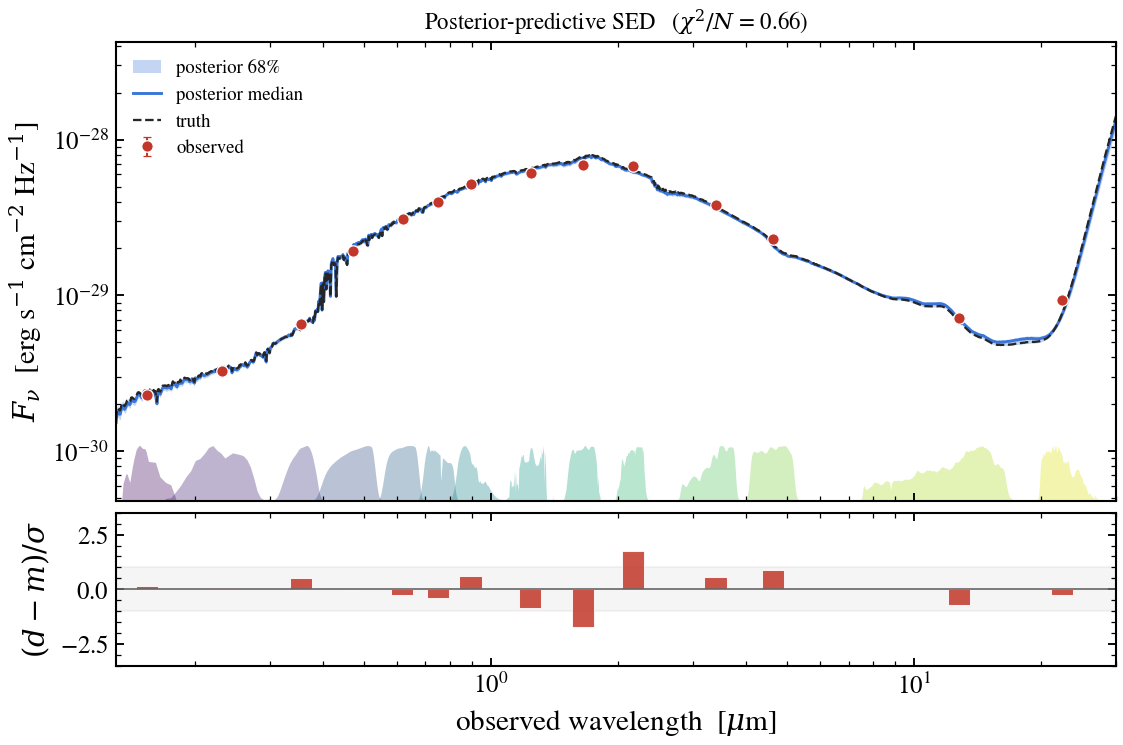

In [9]:
WAVE_OBS = np.geomspace(1300.0, 3e5, 1200)  # 0.13–30 μm, GALEX → WISE W4
z_obs = float(truth_full["redshift"])
dl_cm = cosmology.luminosity_distance(z_obs)


def obs_fnu(params):
    pred = sed_model.predict(params)
    lnu_interp = np.interp(
        WAVE_OBS / (1.0 + z_obs), np.asarray(sed_model.wavelengths), np.asarray(pred.rest_sed())
    )
    return np.asarray(lnu_to_fnu(jnp.asarray(lnu_interp), dl_cm, z_obs))


spec_draws = np.stack([obs_fnu(p) for p in draw_dicts(60)])
spec_lo, spec_med, spec_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
spec_truth = obs_fnu(truth_full)

# Use predict_photometry (the WavePrecomp LUT path the mock was generated with)
# for the model fluxes, so the posterior photometry is consistent with the fit
# and the residuals aren't inflated by a mismatched forward path.
phot_draws = np.stack([np.asarray(sed_model.predict_photometry(p)) for p in draw_dicts(N_DRAWS)])
phot_med = np.median(phot_draws, axis=0)

resid = (flux_obs - phot_med) / noise
chi2_dof = float(np.sum(resid**2) / len(resid))

fig = plt.figure(figsize=(8.6, 5.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.04)
ax, ax_res = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
wave_um = WAVE_OBS / 1e4

band_palette = plt.cm.viridis(np.linspace(0.05, 0.95, len(phot.filter_waves)))
ymin, ymax = 0.3 * spec_truth.min(), 3 * spec_truth.max()
for fw, ft, color in zip(phot.filter_waves, phot.filter_trans, band_palette):
    fw_um = np.asarray(fw) / 1e4
    ft_norm = np.asarray(ft) / np.max(ft)
    band = ymin * (ymax / ymin) ** (0.12 * ft_norm)
    ax.fill_between(fw_um, ymin, band, color=color, alpha=0.35, lw=0)

ax.fill_between(wave_um, spec_lo, spec_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax.plot(wave_um, spec_med, color=C_POST, lw=1.4, label="posterior median")
ax.plot(wave_um, spec_truth, color=C_TRUTH, lw=1.1, ls="--", label="truth")
ax.errorbar(
    wave_eff_um,
    flux_obs,
    yerr=noise,
    fmt="o",
    color=C_DATA,
    ms=5.5,
    capsize=2,
    elinewidth=1.0,
    mec="white",
    mew=0.6,
    label="observed",
    zorder=5,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_xlim(wave_um.min(), wave_um.max())
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title(rf"Posterior-predictive SED   ($\chi^2/N$ = {chi2_dof:.2f})", fontsize=11)
plt.setp(ax.get_xticklabels(), visible=False)

ax_res.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_res.axhline(0, color="0.4", lw=0.8)
ax_res.bar(
    wave_eff_um,
    resid,
    width=wave_eff_um * 0.12,
    color=C_DATA,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
ax_res.set_xscale("log")
ax_res.set_xlim(wave_um.min(), wave_um.max())
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_res.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "05_posterior_sed.png", dpi=300, bbox_inches="tight")
plt.show()

## Corner — the age–metallicity–dust degeneracy

Free parameters plus derived quantities, truth dashed. Read the
`met_logzsol`–`dust_tau_diff`–`sfh_tsnorm_*` block: broadband photometry
constrains the stellar mass and the broad SED shape tightly, but the SFH
*shape* parameters and the metallicity–dust split stay correlated and
prior-dominated. That residual degeneracy — not a fitting failure — is
exactly what an optical spectrum
([`06_fitting_spectroscopy`](06_fitting_spectroscopy.py)) breaks.

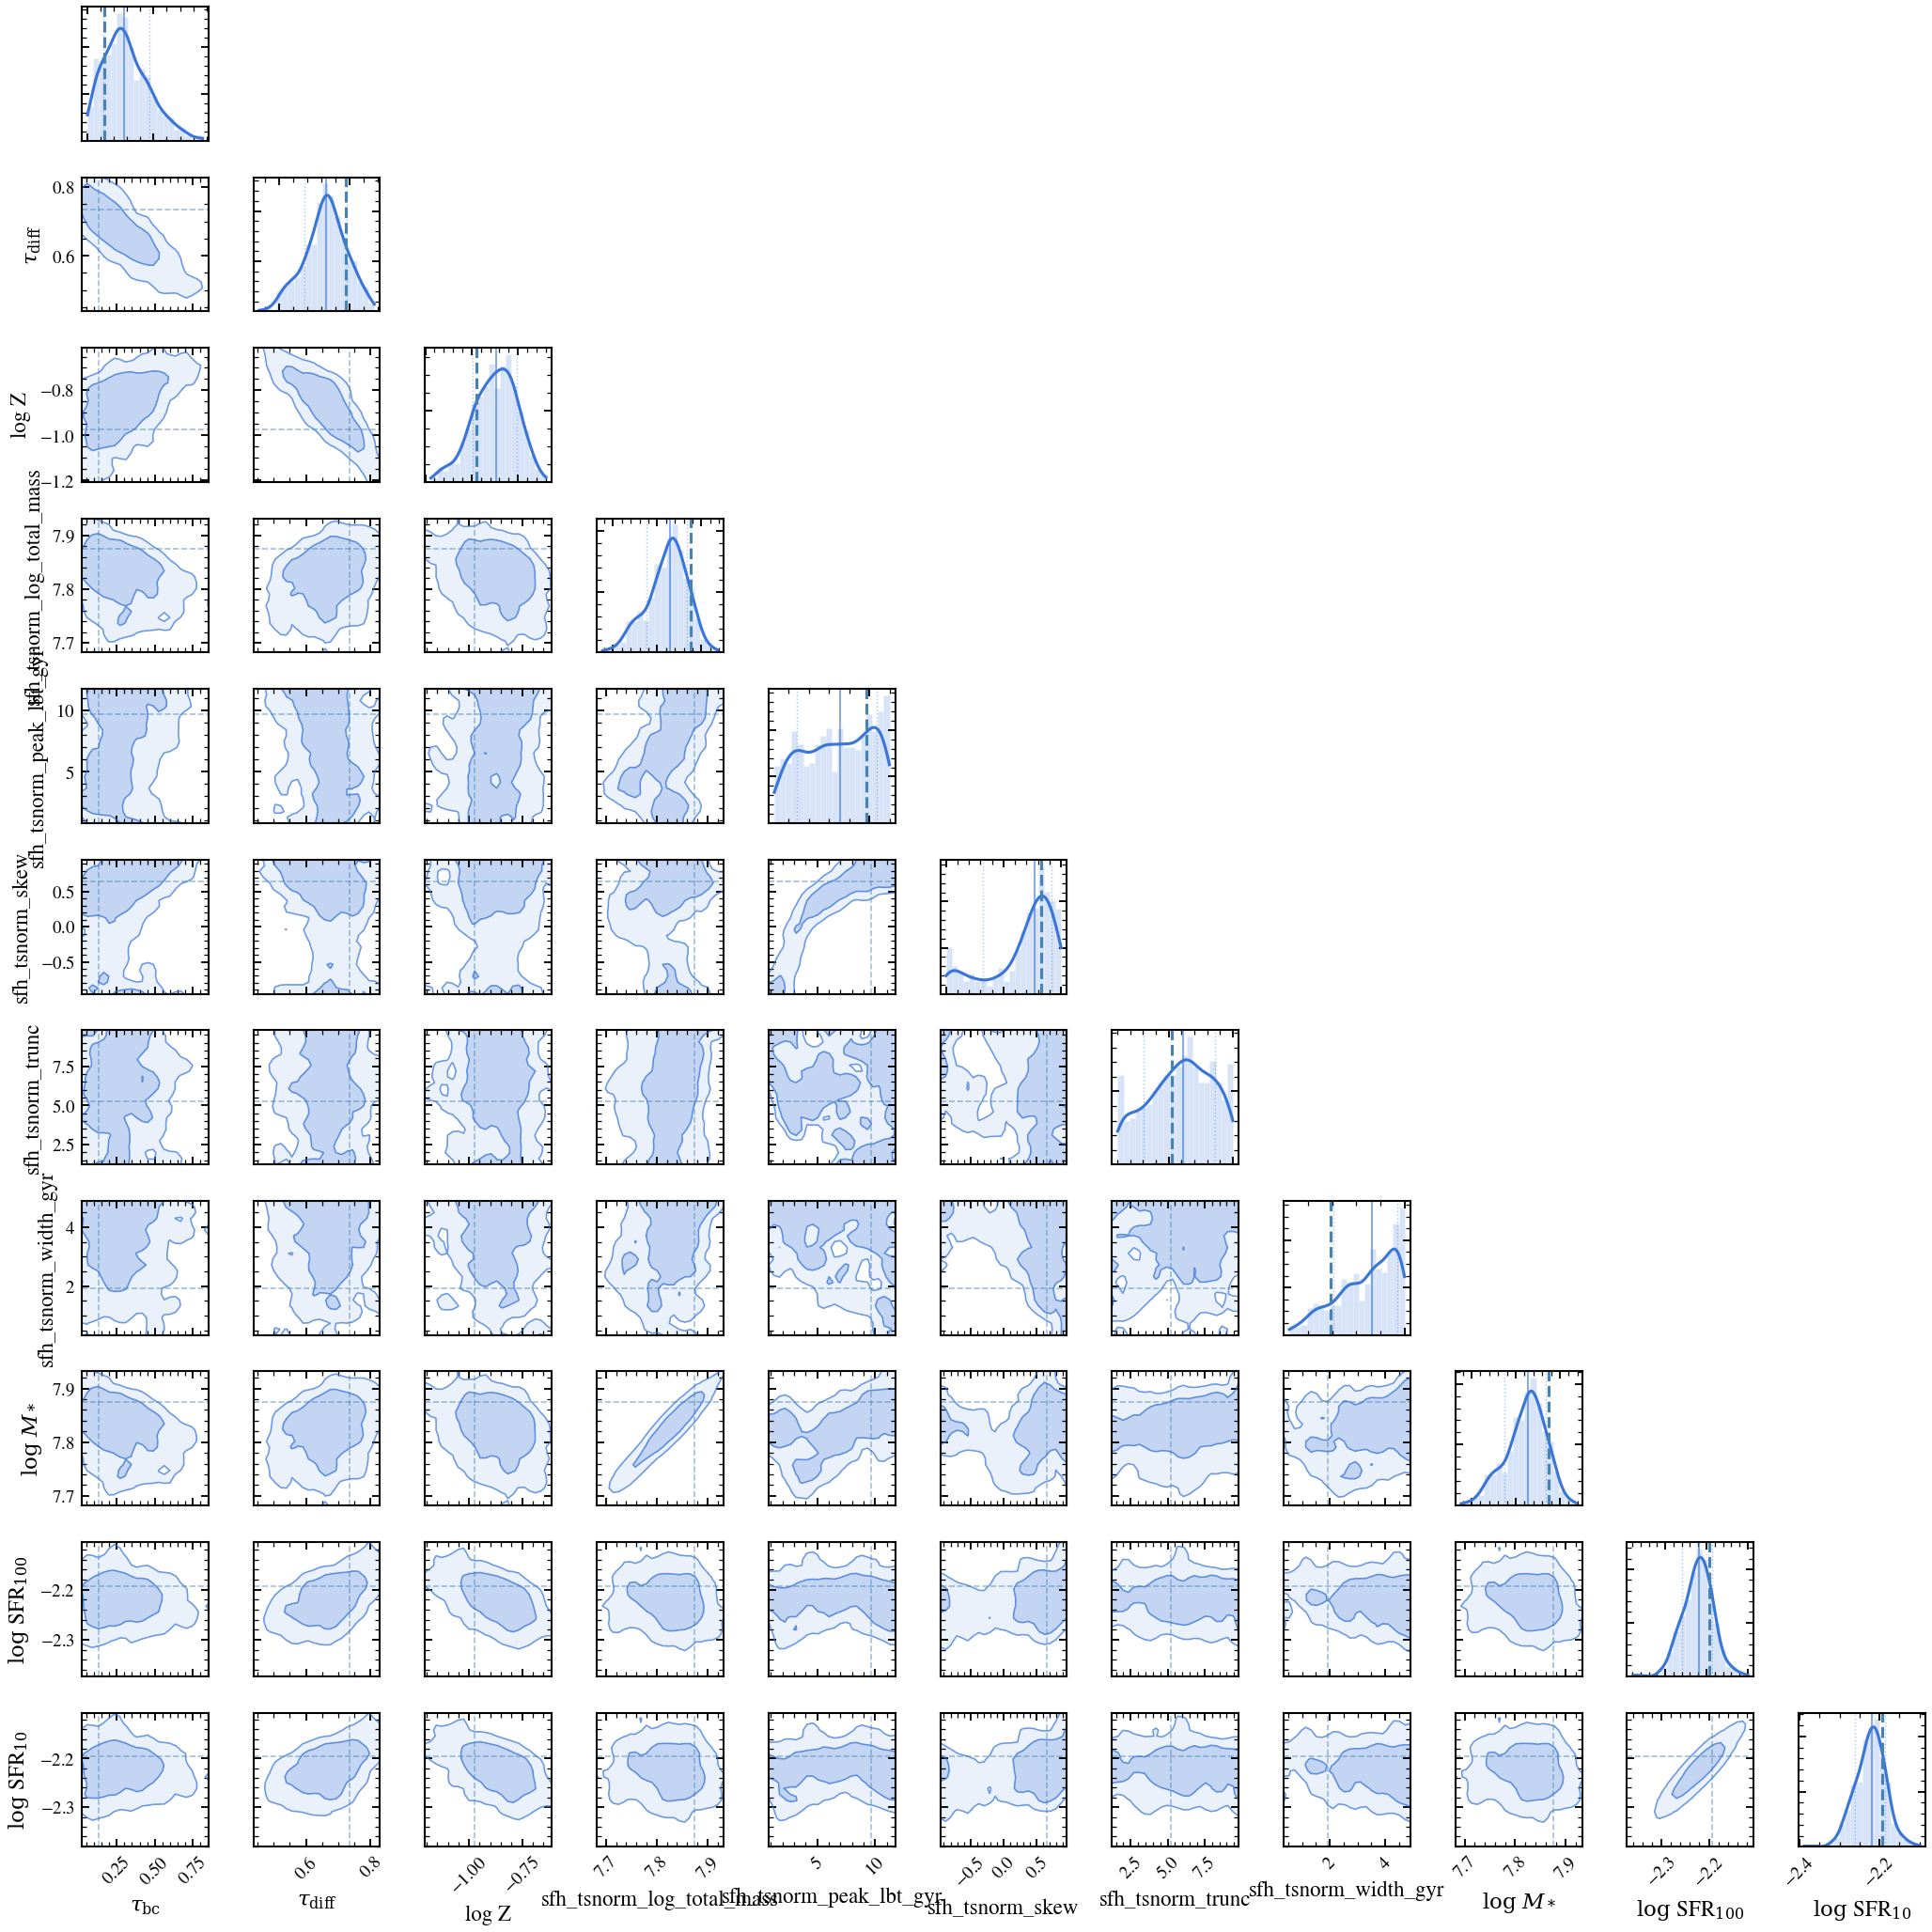

In [10]:
fig_corner = posterior.plot_corner(truths=truth_full, color=C_POST)
fig_corner.savefig(FIG_DIR / "05_corner.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

Same workflow as the quickstart, two more free parameters, and the part that
turns "a fit ran" into "a fit you can publish": split-R̂ and ESS per
parameter, a divergence count, chain traces, and a posterior-predictive χ².
Where the posterior stays broad — the SFH shape, the metallicity–dust split —
that is the physics of broadband photometry, and the diagnostics are what let
you tell that apart from a sampler that simply failed.